# DIGICOM Scratchpad
This is a scratchpad notebook to test your own JupyterLab installation and to show some things that can be helpful for your labwork

## Plotting signals

Plotting is typically done using the `matplotlib` package inside of python. You'll find a simple example below which generates a random signal and plots its power spectrum.

An `matplotlib` API-compatible package called `remote-plot` ([remote-plot](https://pypi.org/project/remote-plot/)) is also useful when operating with VSCode for instance which operates over an `ssh` tunnel. 

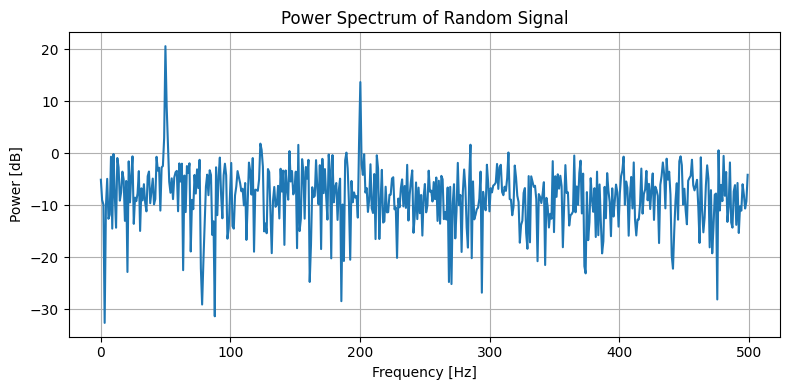

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000            # Sampling frequency (Hz)
N = 1024             # Number of samples
t = np.arange(N) / fs

# Generate a random signal (white noise + two sinusoids)
x = np.random.randn(N) * 0.5 \
    + 0.7*np.sin(2*np.pi*50*t) \
    + 0.3*np.sin(2*np.pi*200*t)

# Compute FFT and power spectrum
X = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)
power_spectrum = np.abs(X)**2 / N   # Power per bin

# Keep only positive frequencies
mask = freqs >= 0
freqs = freqs[mask]
power_spectrum = power_spectrum[mask]

# Plot
plt.figure(figsize=(8,4))
plt.plot(freqs, 10*np.log10(power_spectrum), lw=1.5)
plt.title("Power Spectrum of Random Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [dB]")
plt.grid(True)
plt.tight_layout()
plt.show()


## Some basic statistical analysis tools (auto/cross-correlation)

Here are a couple of useful code snippets for computing auto/cross-correlations. First for autocorrelation

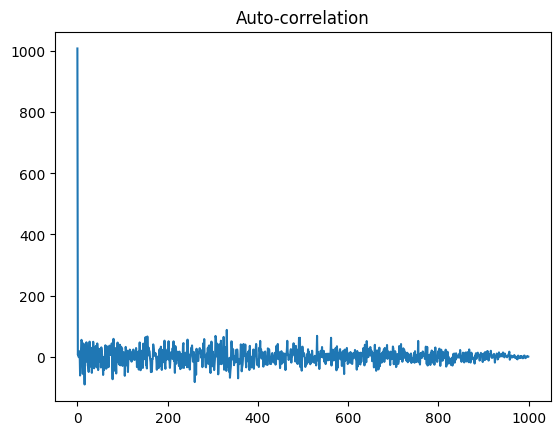

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.randn(1000)
autocorr = np.correlate(x, x, mode='full')
autocorr = autocorr[autocorr.size // 2:]  # keep non-negative lags
plt.plot(autocorr)
plt.title("Auto-correlation")
plt.show()

In [ ]:
Now cross-correlation

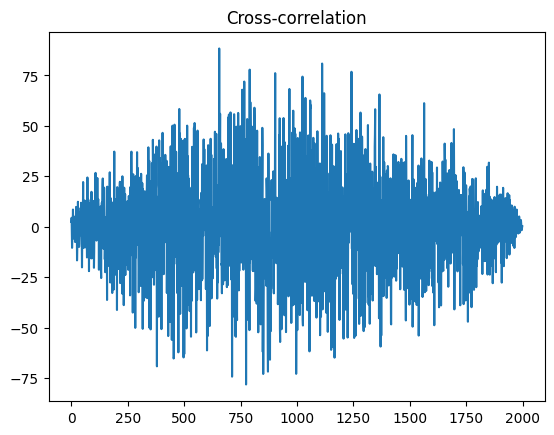

In [4]:
y = np.random.randn(1000)
crosscorr = np.correlate(x, y, mode='full')
plt.plot(crosscorr)
plt.title("Cross-correlation")
plt.show()

You can also use scipy for slightly different versions:

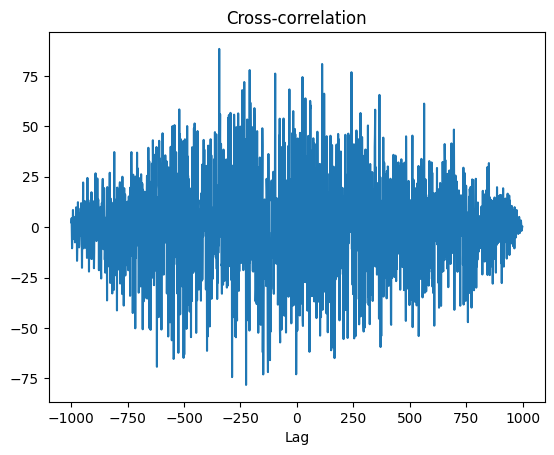

In [5]:
from scipy.signal import correlate, correlation_lags

corr = correlate(x, y, mode='full')
lags = correlation_lags(len(x), len(y), mode='full')
import matplotlib.pyplot as plt
plt.plot(lags, corr)
plt.title("Cross-correlation")
plt.xlabel("Lag")
plt.show()


## Some basic signal processing (convolution)
Here's some sample code for doing convolution, now of complex quantities using both numpy and scipy. They also show more advanced MATLAB-stype plotting using subplots

Max difference: 9.519191346087095e-16


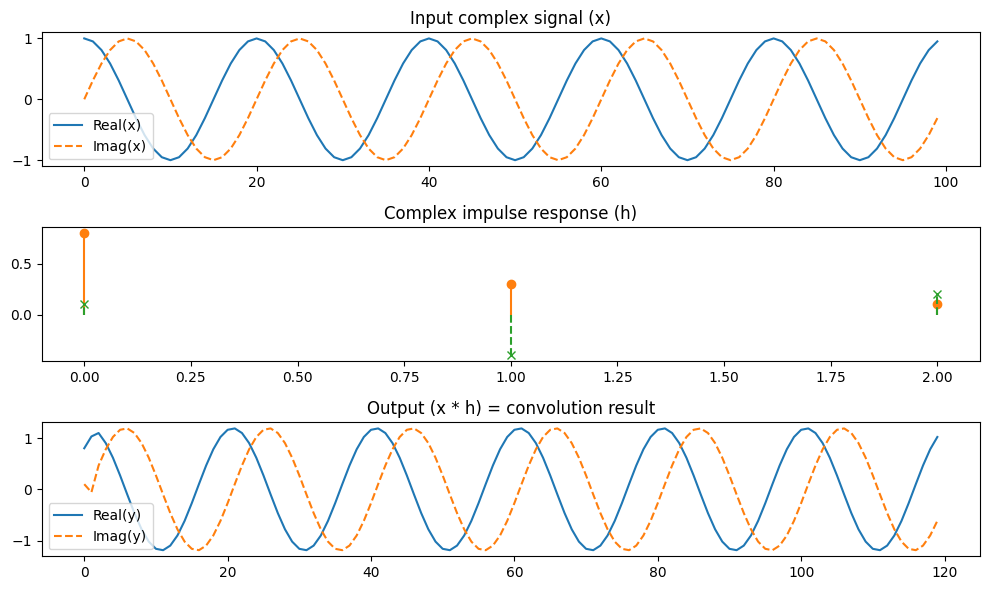

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, fftconvolve

# --- Generate two complex signals ---
fs = 1e3  # sample rate (Hz)
t = np.arange(0, 1, 1/fs)

# Complex exponential (e.g., carrier or tone)
x = np.exp(1j * 2 * np.pi * 50 * t)  # 50 Hz complex tone

# Complex "channel" impulse response (multipath-like)
h = np.array([0.8 + 0.1j, 0.3 - 0.4j, 0.1 + 0.2j])

# --- Perform convolution ---
# 1. Direct convolution with numpy
y_np = np.convolve(x, h, mode='full')

# 2. FFT-based convolution (SciPy)
y_fft = fftconvolve(x, h, mode='full')

# Check they’re (almost) identical numerically
print("Max difference:", np.max(np.abs(y_np - y_fft)))

# --- Plot results ---
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(np.real(x[:100]), label='Real(x)')
plt.plot(np.imag(x[:100]), '--', label='Imag(x)')
plt.title("Input complex signal (x)")
plt.legend()

plt.subplot(3,1,2)
plt.stem(np.real(h), linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.stem(np.imag(h), linefmt='C2--', markerfmt='C2x', basefmt=' ')
plt.title("Complex impulse response (h)")

plt.subplot(3,1,3)
plt.plot(np.real(y_np[:120]), label='Real(y)')
plt.plot(np.imag(y_np[:120]), '--', label='Imag(y)')
plt.title("Output (x * h) = convolution result")
plt.legend()

plt.tight_layout()
plt.show()
